In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

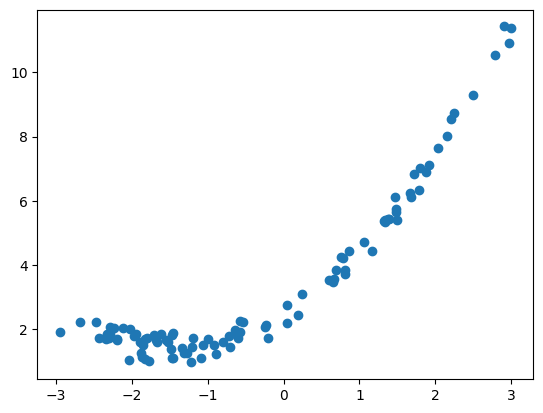

In [2]:
##curved dataset duw to quadratic ax2+bx+y=0

x = 6* np.random.rand(100,1)-3
y= .5 *x**2 + 1.5 *x +2 + np.random.rand (100,1) ##quadratic equation used

plt.scatter(x,y)

In [3]:
from sklearn.model_selection import train_test_split
X_train , X_test , Y_train , Y_test = train_test_split(x,y,test_size=.2 , random_state=42)


In [4]:
from sklearn.linear_model import LinearRegression

regresstion1 = LinearRegression()

In [5]:
regresstion1.fit(X_train , Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [6]:
from sklearn.metrics import r2_score
score = r2_score(Y_test , regresstion1.predict(X_test))
print (score)

0.36304164805268635


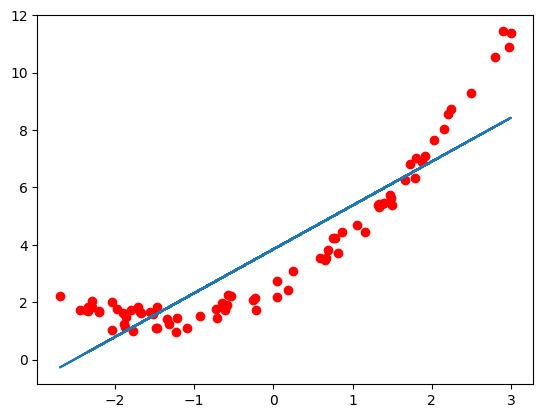

In [7]:
plt.plot(X_train , regresstion1.predict(X_train))

plt.scatter (X_train , Y_train , color = "red")

In [8]:
##polynomial transformation 
from sklearn.preprocessing import PolynomialFeatures

poly= PolynomialFeatures (degree= 2 , include_bias= True)

In [9]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [10]:
X_test_poly

array([[ 1.        ,  0.80963648,  0.65551123],
       [ 1.        , -1.47783233,  2.18398838],
       [ 1.        , -1.94664684,  3.78943391],
       [ 1.        , -2.94862533,  8.69439134],
       [ 1.        , -1.45318858,  2.11175705],
       [ 1.        , -1.26843106,  1.60891735],
       [ 1.        , -2.23182686,  4.98105115],
       [ 1.        , -1.06194491,  1.127727  ],
       [ 1.        , -1.82608646,  3.33459175],
       [ 1.        , -0.89115356,  0.79415467],
       [ 1.        ,  1.67690622,  2.81201447],
       [ 1.        , -2.11669944,  4.4804165 ],
       [ 1.        , -1.82578091,  3.33347594],
       [ 1.        , -2.46628049,  6.08253943],
       [ 1.        , -1.61058391,  2.59398054],
       [ 1.        , -0.99360034,  0.98724163],
       [ 1.        ,  1.46388599,  2.1429622 ],
       [ 1.        , -2.3026621 ,  5.30225274],
       [ 1.        , -0.80076148,  0.64121895],
       [ 1.        , -1.19112657,  1.4187825 ]])

In [12]:
X_train_poly

array([[ 1.00000000e+00, -7.24998309e-01,  5.25622548e-01],
       [ 1.00000000e+00, -1.96976809e+00,  3.87998635e+00],
       [ 1.00000000e+00,  2.97828971e+00,  8.87020957e+00],
       [ 1.00000000e+00, -2.68898713e+00,  7.23065177e+00],
       [ 1.00000000e+00,  6.71135780e-01,  4.50423236e-01],
       [ 1.00000000e+00, -1.33731808e+00,  1.78841965e+00],
       [ 1.00000000e+00,  1.05533661e+00,  1.11373535e+00],
       [ 1.00000000e+00, -2.10689181e-01,  4.43899309e-02],
       [ 1.00000000e+00,  1.66648952e+00,  2.77718732e+00],
       [ 1.00000000e+00, -1.70413125e+00,  2.90406331e+00],
       [ 1.00000000e+00,  5.93520856e-01,  3.52267007e-01],
       [ 1.00000000e+00, -2.02731138e+00,  4.10999142e+00],
       [ 1.00000000e+00, -1.21083959e+00,  1.46613251e+00],
       [ 1.00000000e+00,  1.15970494e+00,  1.34491555e+00],
       [ 1.00000000e+00,  1.91997838e+00,  3.68631699e+00],
       [ 1.00000000e+00, -1.66287298e+00,  2.76514655e+00],
       [ 1.00000000e+00, -6.08598939e-01

In [16]:
from sklearn.metrics import r2_score
regression = LinearRegression()
regression.fit(X_train_poly, Y_train)
y_pred = regression.predict (X_test_poly)
score = r2_score(Y_test , y_pred)
print (score)

0.9505064656234377


In [18]:
print (regression.coef_)

[[0.         1.47566932 0.51087854]]


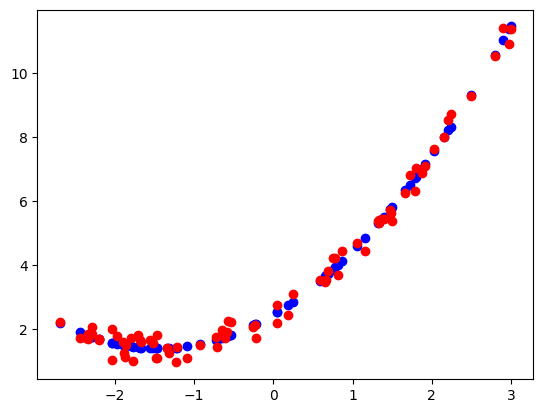

In [25]:
plt.scatter (X_train , regression.predict(X_train_poly) , color ="blue") ##model

plt.scatter(X_train , Y_train , color="r") ##data

In [28]:
## pipelining -generic function to the curve
from sklearn.pipeline import Pipeline
def poly_regression(degree):
    X_new = np.linspace(-3, 3, 200).reshape(200, 1)
    
    poly_features=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_regression=Pipeline([
        ("poly_features",poly_features),
        ("lin_reg",lin_reg)
    ])
    poly_regression.fit(X_train,y_train) ## ploynomial and fit of linear reression
    y_pred_new=poly_regression.predict(X_new)
    #plotting prediction line
    plt.plot(X_new, y_pred_new,'r', label="Degree " + str(degree), linewidth=2)
    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-4,4, 0, 10])
    plt.show()
    

In [30]:
poly_regression(16)

NameError: name 'y_train' is not defined